In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [2]:
df = pd.read_excel(r'C:\Users\mahdi\Downloads\mp_dataset_processed.xlsx')
df

,Formulation Index,Drug MW,Drug TPSA,Drug LogP,Polymer MW,LA/GA,Initial Drug-to-Polymer Ratio,Particle Size,Drug Loading Capacity,Drug Encapsulation Efficiency,Solubility Enhancer Concentration,Time,Release
0,1,639.830,116.04,5.7289,75.0,3.0,0.666667,47.723,35.41,88.30,0.5,0.000000,0.000000
1,1,639.830,116.04,5.7289,75.0,3.0,0.666667,47.723,35.41,88.30,0.5,1.889764,0.062622
2,1,639.830,116.04,5.7289,75.0,3.0,0.666667,47.723,35.41,88.30,0.5,7.181102,0.056751
3,1,639.830,116.04,5.7289,75.0,3.0,0.666667,47.723,35.41,88.30,0.5,13.984252,0.058708
4,1,639.830,116.04,5.7289,75.0,3.0,0.666667,47.723,35.41,88.30,0.5,27.968504,0.058708
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4908,321,360.406,84.12,1.1031,20.0,3.0,0.112347,42.360,7.96,80.16,0.0,3.078327,0.210131
4909,321,360.406,84.12,1.1031,20.0,3.0,0.112347,42.360,7.96,80.16,0.0,7.068903,0.337711
4910,321,360.406,84.12,1.1031,20.0,3.0,0.112347,42.360,7.96,80.16,0.0,14.089168,0.613508
4911,321,360.406,84.12,1.1031,20.0,3.0,0.112347,42.360,7.96,80.16,0.0,21.110465,0.911820


In [3]:
print(df.shape)
print(df.head())
print(df.describe())
print(df.isnull().sum())

(4913, 13)
   Formulation Index  Drug MW  Drug TPSA  Drug LogP  Polymer MW  LA/GA  \
0                  1   639.83     116.04     5.7289        75.0    3.0   
1                  1   639.83     116.04     5.7289        75.0    3.0   
2                  1   639.83     116.04     5.7289        75.0    3.0   
3                  1   639.83     116.04     5.7289        75.0    3.0   
4                  1   639.83     116.04     5.7289        75.0    3.0   

   Initial Drug-to-Polymer Ratio  Particle Size  Drug Loading Capacity  \
0                       0.666667         47.723                  35.41   
1                       0.666667         47.723                  35.41   
2                       0.666667         47.723                  35.41   
3                       0.666667         47.723                  35.41   
4                       0.666667         47.723                  35.41   

   Drug Encapsulation Efficiency  Solubility Enhancer Concentration  \
0                           

In [4]:

# Cap release again
df['Release'] = df['Release'].clip(upper=1.0)

# Check formulation index column
print(df.columns.tolist())
print(f"Total rows: {len(df)}")
print(f"Unique formulations: {df['Formulation Index'].nunique()}")
print(f"Average time points per formulation: {len(df)/df['Formulation Index'].nunique():.1f}")

['Formulation Index', 'Drug MW', 'Drug TPSA', 'Drug LogP', 'Polymer MW', 'LA/GA', 'Initial Drug-to-Polymer Ratio', 'Particle Size', 'Drug Loading Capacity', 'Drug Encapsulation Efficiency', 'Solubility Enhancer Concentration', 'Time', 'Release']
Total rows: 4913
Unique formulations: 321
Average time points per formulation: 15.3


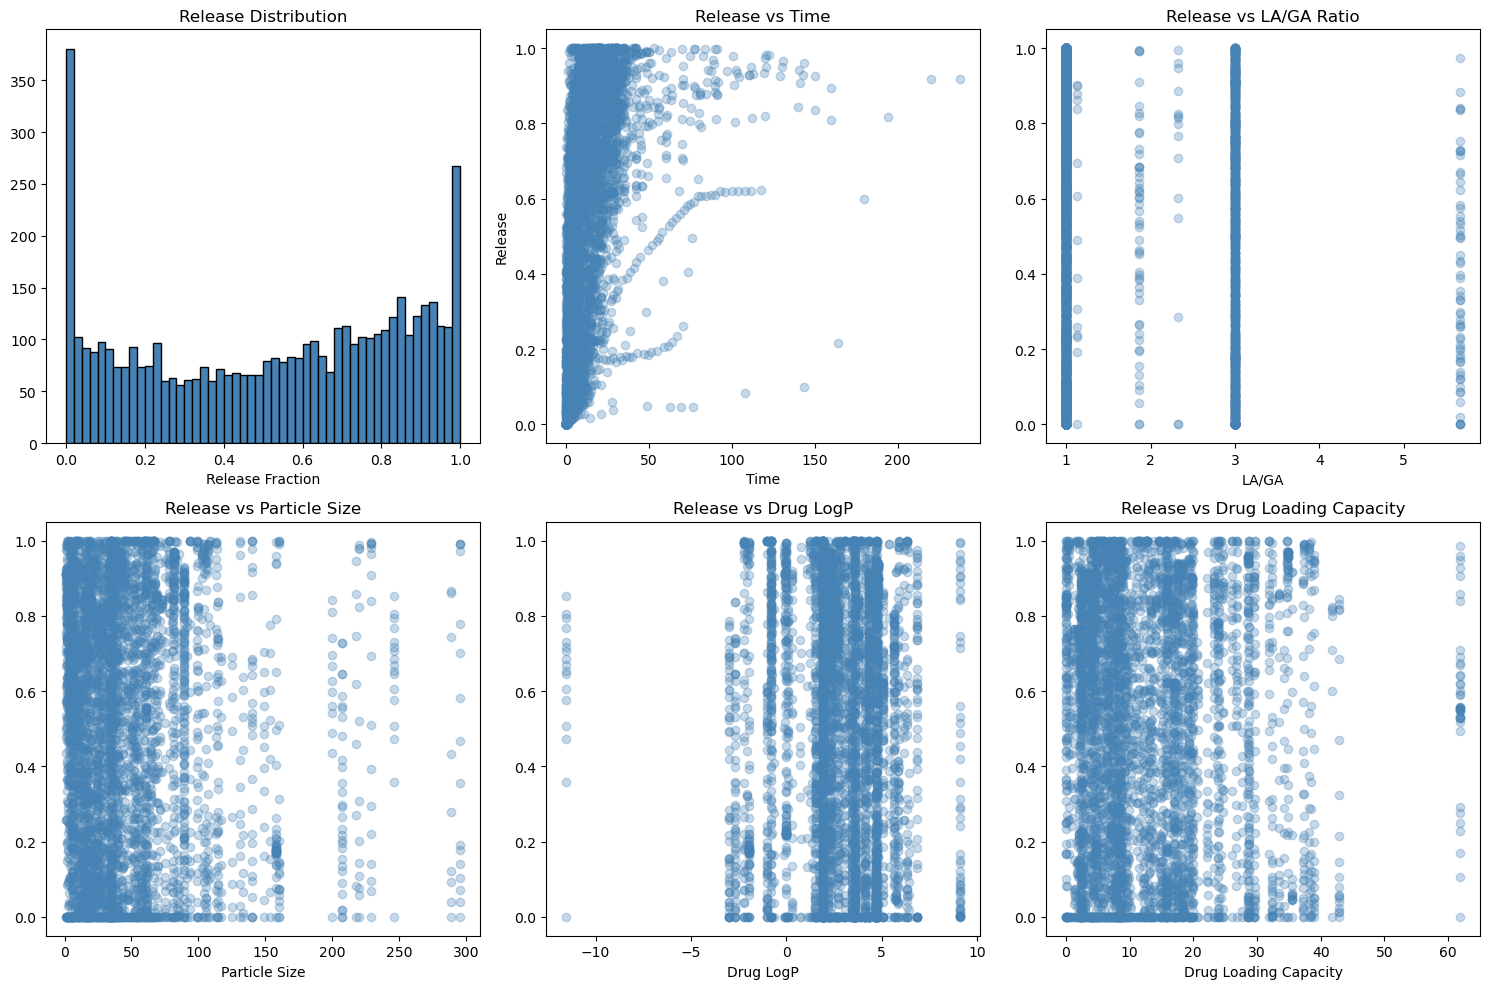

       Formulation Index      Drug MW    Drug TPSA    Drug LogP   Polymer MW  \
count        4913.000000  4913.000000  4913.000000  4913.000000  4913.000000   
mean          159.926114   425.801951    98.734586     2.699395    40.122857   
std            90.672849   213.651324    85.082568     2.315395    30.042887   
min             1.000000   130.078000     6.480000   -11.545200     2.300000   
25%            85.000000   312.442000    41.130000     1.895700    12.000000   
50%           152.000000   392.467000    88.540000     2.656500    34.000000   
75%           241.000000   480.901000    94.830000     4.335420    46.000000   
max           321.000000  1488.807000   701.770000     9.113520   215.000000   

             LA/GA  Initial Drug-to-Polymer Ratio  Particle Size  \
count  4913.000000                    4913.000000    4913.000000   
mean      1.573165                       0.254164      45.146116   
std       0.978081                       0.258735      45.053940   
min    

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. Release distribution
axes[0,0].hist(df['Release'], bins=50, color='steelblue', edgecolor='black')
axes[0,0].set_title('Release Distribution')
axes[0,0].set_xlabel('Release Fraction')

# 2. Release vs Time
axes[0,1].scatter(df['Time'], df['Release'], alpha=0.3, color='steelblue')
axes[0,1].set_title('Release vs Time')
axes[0,1].set_xlabel('Time')
axes[0,1].set_ylabel('Release')

# 3. Release vs LA/GA
axes[0,2].scatter(df['LA/GA'], df['Release'], alpha=0.3, color='steelblue')
axes[0,2].set_title('Release vs LA/GA Ratio')
axes[0,2].set_xlabel('LA/GA')

# 4. Release vs Particle Size
axes[1,0].scatter(df['Particle Size'], df['Release'], alpha=0.3, color='steelblue')
axes[1,0].set_title('Release vs Particle Size')
axes[1,0].set_xlabel('Particle Size')

# 5. Release vs Drug LogP
axes[1,1].scatter(df['Drug LogP'], df['Release'], alpha=0.3, color='steelblue')
axes[1,1].set_title('Release vs Drug LogP')
axes[1,1].set_xlabel('Drug LogP')

# 6. Release vs Drug Loading Capacity
axes[1,2].scatter(df['Drug Loading Capacity'], df['Release'], alpha=0.3, color='steelblue')
axes[1,2].set_title('Release vs Drug Loading Capacity')
axes[1,2].set_xlabel('Drug Loading Capacity')

plt.tight_layout()
plt.show()

# Summary statistics
print(df.describe())

In [6]:
from sklearn.model_selection import GroupShuffleSplit
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Split by formulation — not by row
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

groups = df['Formulation Index']
X = df.drop(columns=['Formulation Index', 'Release'])
y = df['Release']

train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(f"Train rows: {len(X_train)}")
print(f"Test rows:  {len(X_test)}")
print(f"Train formulations: {df['Formulation Index'].iloc[train_idx].nunique()}")
print(f"Test formulations:  {df['Formulation Index'].iloc[test_idx].nunique()}")

Train rows: 3935
Test rows:  978
Train formulations: 256
Test formulations:  65


In [7]:
from sklearn.model_selection import cross_val_score
configs = [
    (0.01, 500),
    (0.01, 1000),
    (0.01, 2000),
    (0.1,  500),
]
print(f"{'LR':<8} {'Trees':<8} {'Train R²':<12} {'Test R²':<12} {'MAE':<10} {'RMSE':<10} {'Gap':<10}")
for l, n in configs:
    model = XGBRegressor(
    n_estimators = n,
    max_depth = 6,
    learning_rate=l,
    random_state = 42
    )

    model.fit(X_train, y_train)
    yhat = model.predict(X_test)
    train_R2 = r2_score(y_train, model.predict(X_train))
    test_R2 = r2_score(y_test, yhat)
    MAE =  mean_absolute_error(y_test, yhat)
    RMSE = np.sqrt(mean_squared_error(y_test, yhat)) 
    print(f"{l:<8} {n:<8} {train_R2:<12.3f} {test_R2:<12.3f} {MAE:<10.3f} {RMSE:<10.3f} {train_R2 - test_R2:<10.3f}")

    

LR       Trees    Train R²     Test R²      MAE        RMSE       Gap       
0.01     500      0.918        0.734        0.128      0.171      0.185     
0.01     1000     0.962        0.743        0.124      0.168      0.219     
0.01     2000     0.982        0.741        0.123      0.169      0.241     
0.1      500      0.995        0.721        0.129      0.175      0.274     


In [8]:
# Pre-synthesis features only
pre_synthesis_cols = ['Drug MW', 'Drug TPSA', 'Drug LogP',
                      'Polymer MW', 'LA/GA',
                      'Initial Drug-to-Polymer Ratio',
                      'Solubility Enhancer Concentration',
                      'Time']

X_pre = df[pre_synthesis_cols]
y = df['Release']

In [9]:
gss_new = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
groups = df['Formulation Index']
train_idx_, test_idx_ = next(gss_new.split(X_pre, y, groups))
X_train_, X_test_ = X_pre.iloc[train_idx_], X_pre.iloc[test_idx_]
y_train_, y_test_ = y.iloc[train_idx_], y.iloc[test_idx_]

xgb = XGBRegressor(
    n_estimators = 1000,
    max_depth = 6,
    learning_rate = 0.01,
    random_state = 85
)

xgb.fit(X_train_, y_train_)
print(f'trian_R2: {r2_score(y_train_, xgb.predict(X_train_)):.3f}')
print(f'test_R2: {r2_score(y_test_, xgb.predict(X_test_)):.3f}')
print(f'MAE: {mean_absolute_error(y_test_, xgb.predict(X_test_)):.3f}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test_, xgb.predict(X_test_))):.3f}')

trian_R2: 0.920
test_R2: 0.703
MAE: 0.132
RMSE: 0.181


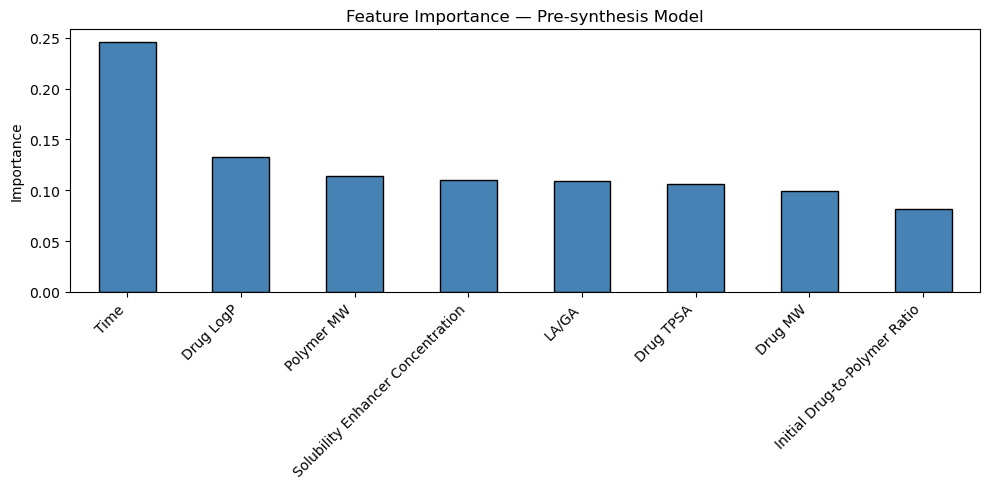

Time                                 0.245964
Drug LogP                            0.133196
Polymer MW                           0.114001
Solubility Enhancer Concentration    0.110208
LA/GA                                0.109513
Drug TPSA                            0.106467
Drug MW                              0.098936
Initial Drug-to-Polymer Ratio        0.081716
dtype: float32


In [10]:
# Step 1 - Define pre-synthesis features
pre_synthesis_cols = ['Drug MW', 'Drug TPSA', 'Drug LogP',
                      'Polymer MW', 'LA/GA',
                      'Initial Drug-to-Polymer Ratio',
                      'Solubility Enhancer Concentration',
                      'Time']

# Step 2 - Create X and y
X_pre = df[pre_synthesis_cols]
y = df['Release']

# Step 3 - Split by formulation
groups = df['Formulation Index']
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_pre, y, groups))

X_train_pre = X_pre.iloc[train_idx]
X_test_pre  = X_pre.iloc[test_idx]
y_train_pre = y.iloc[train_idx]
y_test_pre  = y.iloc[test_idx]

# Step 4 - Train model
model_pre = XGBRegressor(n_estimators=1000, max_depth=6, 
                          learning_rate=0.01, random_state=42)
model_pre.fit(X_train_pre, y_train_pre)

# Step 5 - Feature importance
importances = pd.Series(
    model_pre.feature_importances_,
    index=pre_synthesis_cols
).sort_values(ascending=False)

plt.figure(figsize=(10,5))
importances.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Feature Importance — Pre-synthesis Model')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(importances)

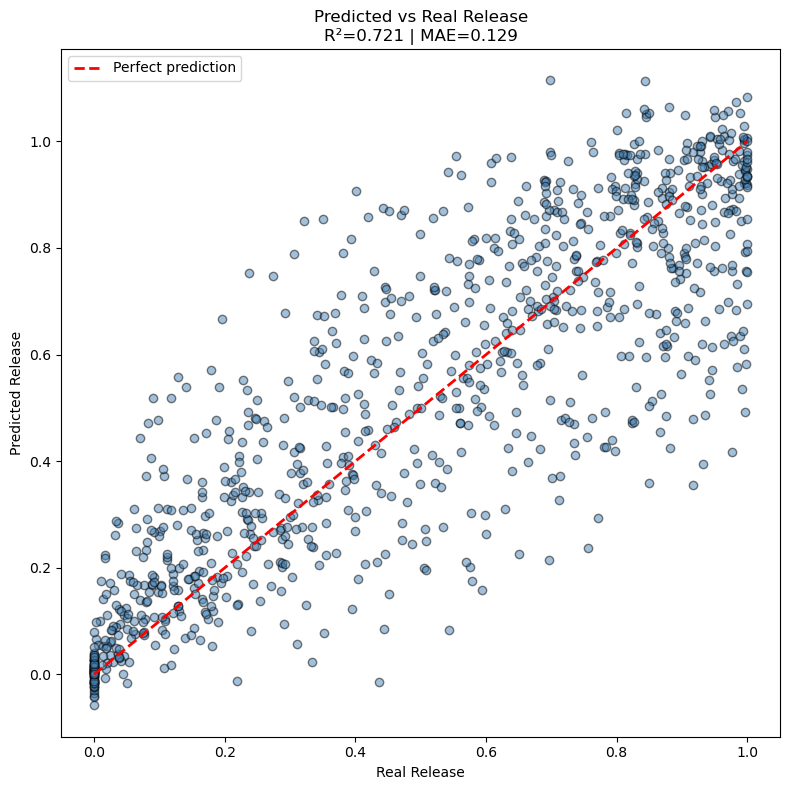

In [11]:
# Predicted vs Actual plot
y_pred = model.predict(X_test)

plt.figure(figsize=(8,8))
plt.scatter(y_test, y_pred, alpha=0.5, color='steelblue', edgecolor='black')
plt.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Perfect prediction')
plt.xlabel('Real Release')
plt.ylabel('Predicted Release')
plt.title(f'Predicted vs Real Release\nR²={r2_score(y_test, y_pred):.3f} | MAE={mean_absolute_error(y_test, y_pred):.3f}')
plt.legend()
plt.tight_layout()
plt.show()